# Adaptive CYCBD (ACYCBD)

Second-order cyclostationarity is the natural language of a repeating
impact through a linear channel: the instantaneous power of $y$ has
Fourier coefficients at a cyclic frequency $\alpha$ and its
harmonics. **CYCBD** (Buzzoni, Antoni & D'Elia, JSV 2018) maximises
that ICS2 criterion by solving the generalised eigenproblem

$$XWX\,h=\kappa\,XX\,h$$

for the inverse FIR $h$. The weight $W$ is a periodic projection
of $|y|^p$ onto the harmonics of a **known** $\alpha$. As with
MCKD, a wrong prior cyclic frequency makes the filter fail.

**ACYCBD** (Zhang, Miao, Lin & Yi, MSSP 2021) estimates $\alpha$
each iteration from the **envelope harmonic-product spectrum** (EHPS)
of the current output, rebuilds $W$, and updates $h$ until the
relative change in $\kappa$ falls below ``param.RE`` (default
$10^{-3}$) or 50 iterations elapse.

$$P(f)=\prod_{k=1}^{K}\bigl|E(kf)\bigr|,\qquad
\hat\alpha=\arg\max_f P(f).$$

The estimated fundamental is then fed to CYCBD as
$\alpha_k=k\hat\alpha$, $k=1,\ldots,100$.

| | **CYCBD** | **ACYCBD** (this notebook) |
|---|---|---|
| Cyclic frequency | geometry $\times$ RPM | EHPS of current $s$ |
| Linear algebra | $XWX\,h=\kappa\,XX\,h$ | same, with adapted $W$ |
| Output | FIR and trimmed $s$ | FIR, $s$, and $\hat\alpha$ versus iteration |

**References**

> B. Zhang, Y. Miao, J. Lin, Y. Yi, *Adaptive maximum second-order
> cyclostationarity blind deconvolution and its application for
> locomotive bearing fault diagnosis*, Mechanical Systems and Signal
> Processing 158 (2021) 107736.

> M. Buzzoni, J. Antoni, G. D'Elia, *Blind deconvolution based on
> cyclostationarity maximization and its application to fault
> identification*, Journal of Sound and Vibration 432 (2018) 569–601.


## 1. Imports


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

print("pysdkit from:", Path(__import__("pysdkit").__file__).resolve())

from pysdkit.data import load_acycbd_sig2
from pysdkit.utils import acycbd, annotate_harmonics, envelope_spectrum, matlab_kurtosis

pysdkit from: C:\Users\whenx\Desktop\PySDKit\pysdkit\__init__.py


## 2. What the code computes

1. Demean $x$. Initialise $h$ as a delayed impulse ($h_2=1$).
2. Build the unweighted correlation $XX=\mathrm{CorrMatrix}(x)$ once.
3. Filter $s=h*x$ (causal ``lfilter``). Weights start as
   $W=|s_{N:L}|^p$ with $p=2$.
4. $\hat\alpha=\mathrm{EHPS}(s)$ on the mean-centred Hilbert
   envelope spectrum (DC dropped; product of $K=10$ harmonics;
   search limited by MATLAB ``flim=300``).
5. Project $W$ onto harmonics of $\hat\alpha$ (real Fourier
   series) and zero bins below $\mathrm{mean}+2\,\mathrm{std}$.
6. Solve the largest-magnitude generalised eigenpair of
   $(XWX,\,XX)$; stop when
   $|\kappa-\kappa_{\mathrm{old}}|/|\kappa_{\mathrm{old}}|$
   is small. The first error is $\infty$ because
   $\kappa_{\mathrm{old}}=0$.
7. Return $s=h*x$ trimmed to the valid FIR region
   (MATLAB ``s(N:end)``, length $L-N+1$).

EHPS needs a record of about one second at the given $f_s$ so that
``round(flim * fs / L)`` bins cover a few hundred hertz. It returns
**one** fundamental; several incommensurate periods of similar
strength will collapse to a single line.

Use this when the interesting cycle lives in the **envelope** (AM of
a resonant carrier). A pure sinusoid has a flat envelope, and EHPS
is then unstable — SST / SET are the right tools for carrier
instantaneous frequency.


## 3. MATLAB demo (``02 ACYCBD/demo.m``)

Packaged ``sig2.mat``: 20000 samples, $f_s=20\,\mathrm{kHz}$,
inner-race frequency **BPFI = 47 Hz**. Call
``ACYCBD(x, fs, 40)``.


N = 20000 fs = 20000.0 BPFI = 47.0


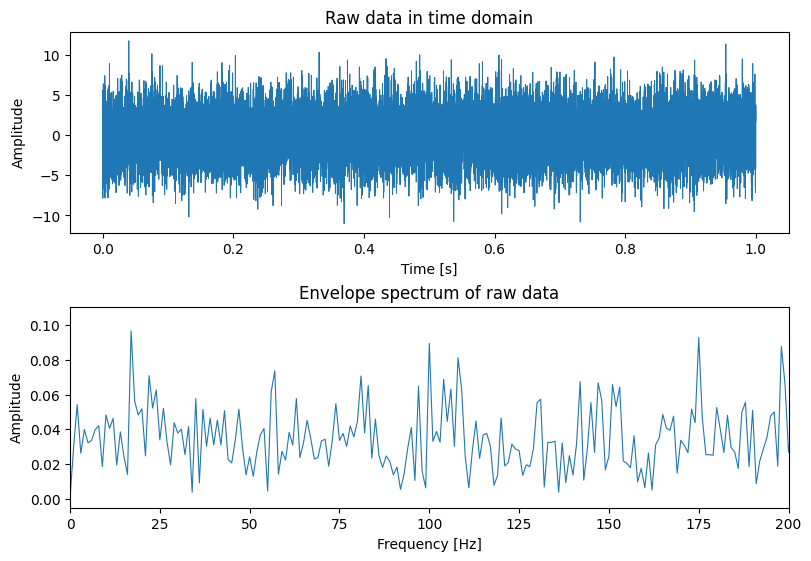

In [2]:
record = load_acycbd_sig2()
x = record["signal"] - np.mean(record["signal"])
fs = float(record["fs"])
t = record["t"]
bpfi = float(record["bpfi"])
print("N =", x.size, "fs =", fs, "BPFI =", bpfi)

freq_x, spec_x = envelope_spectrum(x, fs, scale="length")
fig, axes = plt.subplots(2, 1, figsize=(8, 5.5), constrained_layout=True)
axes[0].plot(t, x, color="C0", lw=0.7)
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Amplitude")
axes[0].set_title("Raw data in time domain")
axes[1].plot(freq_x, spec_x, color="C0", lw=0.8)
axes[1].set_xlim(0, 200)
axes[1].set_xlabel("Frequency [Hz]")
axes[1].set_ylabel("Amplitude")
axes[1].set_title("Envelope spectrum of raw data")
plt.show()

## 4. Run ACYCBD


iterations = 11 kappa = 2.689504157866535
last cyclic frequency = 47.0 Hz


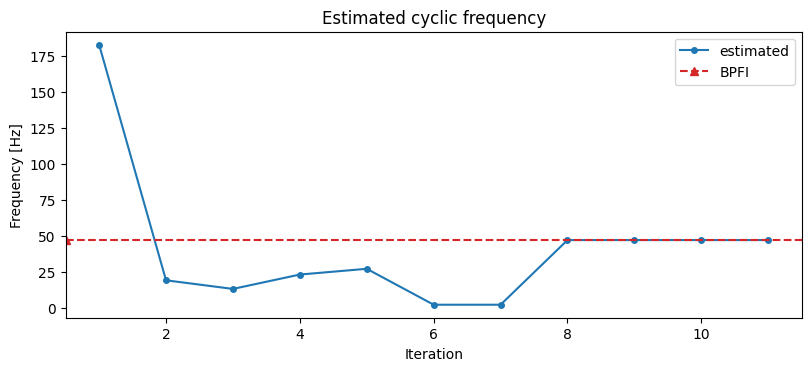

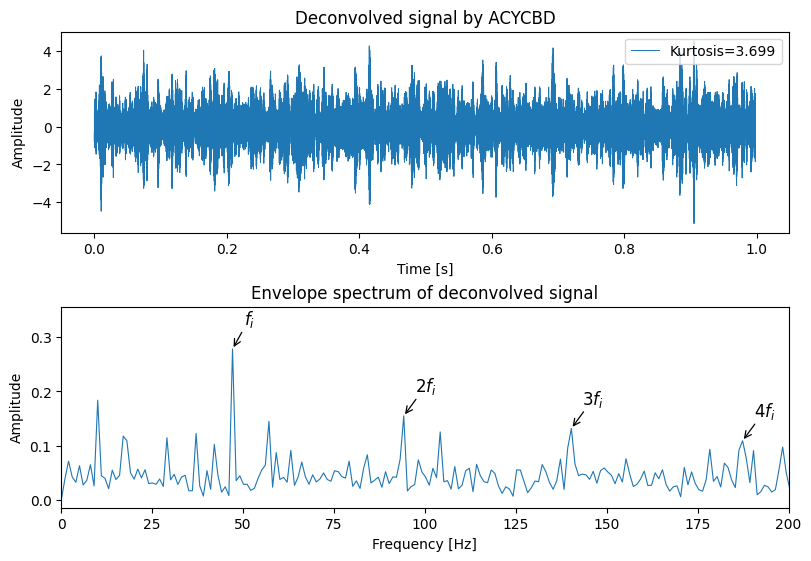

In [3]:
fir, s, info = acycbd(x, fs, filter_size=40)
f_est = np.asarray(info["f_est"], dtype=float)
print("iterations =", info["count"], "kappa =", info["kappa"])
print("last cyclic frequency =", f_est[-1], "Hz")

t_s = np.arange(s.size) / fs
s_d = s - np.mean(s)
freq_s, spec_s = envelope_spectrum(s_d, fs, scale="length")

fig, ax = plt.subplots(figsize=(8, 3.6), constrained_layout=True)
ax.plot(np.arange(1, f_est.size + 1), f_est, "C0-o", ms=4, label="estimated")
ax.axhline(bpfi, color="C3", ls="--", marker="^", markevery=[0], label="BPFI")
ax.set_xlabel("Iteration")
ax.set_ylabel("Frequency [Hz]")
ax.set_title("Estimated cyclic frequency")
ax.legend()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(8, 5.5), constrained_layout=True)
axes[0].plot(t_s, s, color="C0", lw=0.7)
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Amplitude")
axes[0].set_title("Deconvolved signal by ACYCBD")
axes[0].legend([f"Kurtosis={matlab_kurtosis(s):.3f}"], loc="upper right")
axes[1].plot(freq_s, spec_s, color="C0", lw=0.8)
axes[1].set_xlim(0, 200)
axes[1].set_xlabel("Frequency [Hz]")
axes[1].set_ylabel("Amplitude")
axes[1].set_title("Envelope spectrum of deconvolved signal")
annotate_harmonics(freq_s, spec_s, bpfi, n_harmonics=6, ax=axes[1], symbol=r"f_i")
plt.show()